In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [79]:
df=pd.read_csv("teleco.csv")

In [80]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [82]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [83]:
categorical=df.select_dtypes(include="object").columns

In [84]:
for features in categorical:
    print(df[features].value_counts())
    print("------------------")

customerID
7590-VHVEG    1
5575-GNVDE    1
3668-QPYBK    1
7795-CFOCW    1
9237-HQITU    1
             ..
6840-RESVB    1
2234-XADUH    1
4801-JZAZL    1
8361-LTMKD    1
3186-AJIEK    1
Name: count, Length: 7043, dtype: int64
------------------
gender
Male      3555
Female    3488
Name: count, dtype: int64
------------------
Partner
No     3641
Yes    3402
Name: count, dtype: int64
------------------
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
------------------
PhoneService
Yes    6361
No      682
Name: count, dtype: int64
------------------
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
------------------
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
------------------
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64
------------------
OnlineBackup
No                   

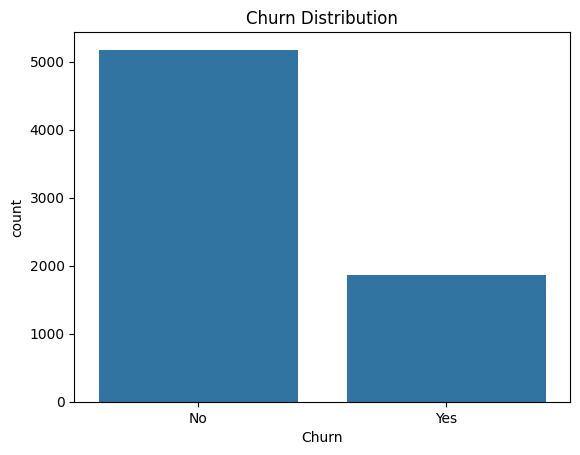

In [85]:
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()

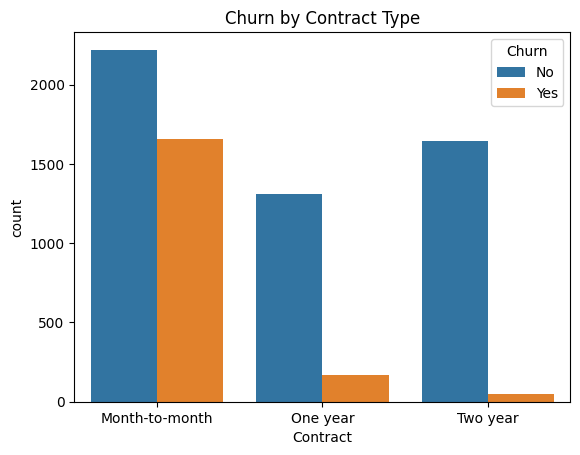

In [86]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Churn by Contract Type')
plt.show()

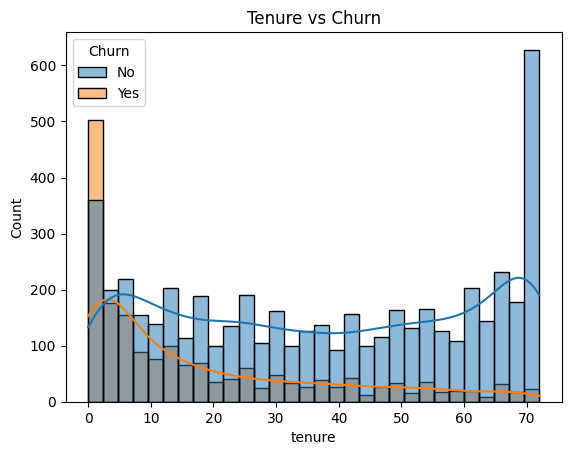

In [87]:
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True)
plt.title('Tenure vs Churn')
plt.show()

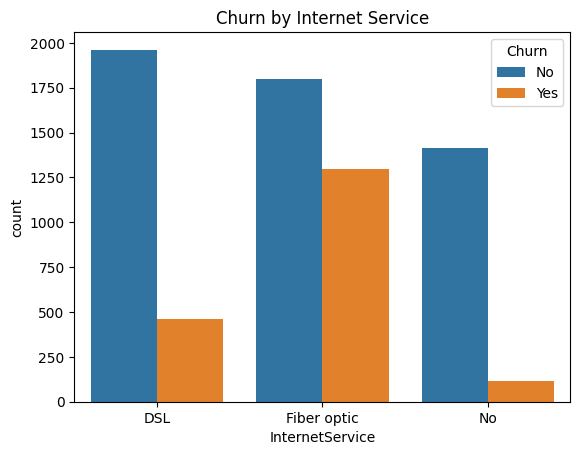

In [88]:
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title('Churn by Internet Service')
plt.show()

In [89]:
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors="coerce")

In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [91]:
from sklearn.preprocessing import LabelEncoder
label=LabelEncoder()

In [92]:
df["Churn"]=label.fit_transform(df["Churn"])

In [93]:
df.drop(["customerID"],axis=1,inplace=True)

In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


This dataset has hidden null values in total charges which we get after preprocessing 

In [95]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df['TotalCharges'].isnull().sum()) 

11


In [96]:
df['TotalCharges'].fillna(0, inplace=True)
print(df['TotalCharges'].isnull().sum())

0


C:\Users\sriva\AppData\Local\Temp\ipykernel_1184\3704478023.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(0, inplace=True)


In [97]:
x=df.drop(["Churn"],axis=1)
y=df["Churn"]

In [98]:
categorical=x.select_dtypes(include="object").columns

In [99]:
categorical

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [100]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

In [101]:
numerical=x.select_dtypes(exclude="object").columns

In [102]:
preprocessor=ColumnTransformer([
("Encoder",OneHotEncoder(),categorical),
("Scaler",StandardScaler(),numerical)
],remainder="passthrough"
)

In [103]:
from sklearn.model_selection import train_test_split

In [104]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.30,random_state=42,stratify=y)

In [105]:
X_train=preprocessor.fit_transform(x_train)

In [106]:
X_test=preprocessor.transform(x_test)

In [107]:
x.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64

In [108]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [109]:
from sklearn.metrics import accuracy_score,classification_report,f1_score,recall_score,precision_score, roc_auc_score

In [110]:
models={
        "Logisitic Regression":LogisticRegression(),
    "Decision Tree":DecisionTreeClassifier(),
    "Random Forest":RandomForestClassifier(),
    "Xgboost":XGBClassifier()
}

In [111]:
for model_name,model in models.items():
    model.fit(X_train,y_train)

    y_train_pred=model.predict(X_train)
    y_test_pred=model.predict(X_test)

    model_train_accuracy = accuracy_score(y_train, y_train_pred) 
    model_train_f1 = f1_score(y_train, y_train_pred, average='weighted')
    model_train_precision = precision_score(y_train, y_train_pred) 
    model_train_recall = recall_score(y_train, y_train_pred) 
    model_train_rocauc_score = roc_auc_score(y_train, y_train_pred)


    model_test_accuracy = accuracy_score(y_test, y_test_pred) 
    model_test_f1 = f1_score(y_test, y_test_pred, average='weighted') 
    model_test_precision = precision_score(y_test, y_test_pred) 
    model_test_recall = recall_score(y_test, y_test_pred) 
    model_test_rocauc_score = roc_auc_score(y_test, y_test_pred)

    print(model_name)
    
    print('Model performance for Training set')
    print("- Accuracy: {:.4f}".format(model_train_accuracy))
    print('- F1 score: {:.4f}'.format(model_train_f1))
    
    print('- Precision: {:.4f}'.format(model_train_precision))
    print('- Recall: {:.4f}'.format(model_train_recall))

    
    print('----------------------------------')
    
    print('Model performance for Test set')
    print('- Accuracy: {:.4f}'.format(model_test_accuracy))
    print('- F1 score: {:.4f}'.format(model_test_f1))
    print('- Precision: {:.4f}'.format(model_test_precision))
    print('- Recall: {:.4f}'.format(model_test_recall))

    
    print('='*35)
    print('\n')
    


Logisitic Regression
Model performance for Training set
- Accuracy: 0.8037
- F1 score: 0.7979
- Precision: 0.6545
- Recall: 0.5505
----------------------------------
Model performance for Test set
- Accuracy: 0.8088
- F1 score: 0.8032
- Precision: 0.6667
- Recall: 0.5597


Decision Tree
Model performance for Training set
- Accuracy: 0.9980
- F1 score: 0.9980
- Precision: 1.0000
- Recall: 0.9924
----------------------------------
Model performance for Test set
- Accuracy: 0.7312
- F1 score: 0.7310
- Precision: 0.4937
- Recall: 0.4920


Random Forest
Model performance for Training set
- Accuracy: 0.9980
- F1 score: 0.9980
- Precision: 0.9962
- Recall: 0.9962
----------------------------------
Model performance for Test set
- Accuracy: 0.7795
- F1 score: 0.7704
- Precision: 0.6077
- Recall: 0.4777


Xgboost
Model performance for Training set
- Accuracy: 0.9497
- F1 score: 0.9494
- Precision: 0.9213
- Recall: 0.8861
----------------------------------
Model performance for Test set
- Accura

Hyperparameter tuning

In [112]:

rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8, 10, None],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', None]
}

xgboost_params = {"learning_rate": [0.1, 0.01],
                  "max_depth": [5, 8, 12, 20, 30],
                  "n_estimators": [100, 200, 300],
                  "colsample_bytree": [0.5, 0.8, 1, 0.3, 0.4]}

lr_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga'],
    'class_weight': ['balanced', None]}

dt_params = {
    'max_depth': [3, 4, 5, 6, 8, 10],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'class_weight': ['balanced']
}



In [113]:
randomcv_models = [
    ("LR",LogisticRegression(),lr_params),
    ("DT",DecisionTreeClassifier(),dt_params),
                   ("RF", RandomForestClassifier(), rf_params),
    ("Xgboost", XGBClassifier(), xgboost_params)
                   
                   ]

In [114]:
from sklearn.model_selection import RandomizedSearchCV

model_param = {}
for name, model, params in randomcv_models:
    random = RandomizedSearchCV(estimator=model,
                                   param_distributions=params,
                                   n_iter=100,
                                   cv=3,
                                   verbose=2,
                                   n_jobs=-1,error_score='raise'
)
    random.fit(X_train, y_train)
    model_param[name] = random.best_params_

for model_name in model_param:
    print(f"---------------- Best Params for {model_name} -------------------")
    print(model_param[model_name])

Fitting 3 folds for each of 20 candidates, totalling 60 fits


e:\ML\yash\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 20 is smaller than n_iter=100. Running 20 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
e:\ML\yash\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 96 is smaller than n_iter=100. Running 96 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 3 folds for each of 96 candidates, totalling 288 fits
Fitting 3 folds for each of 100 candidates, totalling 300 fits
Fitting 3 folds for each of 100 candidates, totalling 300 fits
---------------- Best Params for LR -------------------
{'solver': 'liblinear', 'class_weight': None, 'C': 0.01}
---------------- Best Params for DT -------------------
{'min_samples_split': 2, 'min_samples_leaf': 8, 'max_depth': 4, 'class_weight': 'balanced'}
---------------- Best Params for RF -------------------
{'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 10}
---------------- Best Params for Xgboost -------------------
{'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 1}


In [115]:
models = {
    "Logistic Regression": LogisticRegression(
        solver='liblinear',
        class_weight=None,
        C=0.01
    ),

    "Decision Tree": DecisionTreeClassifier(
        min_samples_split=2,
        min_samples_leaf=8,
        max_depth=4,
        class_weight='balanced'
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        max_depth=8
    ),

    "Xgboost": XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.01,
        colsample_bytree=0.4
    )
}

In [116]:
for model_name,model in models.items():
    model.fit(X_train,y_train)

    y_train_pred=model.predict(X_train)
    y_test_pred=model.predict(X_test)

    model_train_accuracy = accuracy_score(y_train, y_train_pred) 
    model_train_f1 = f1_score(y_train, y_train_pred, average='weighted')
    model_train_precision = precision_score(y_train, y_train_pred) 
    model_train_recall = recall_score(y_train, y_train_pred) 
    model_train_rocauc_score = roc_auc_score(y_train, y_train_pred)


    model_test_accuracy = accuracy_score(y_test, y_test_pred) 
    model_test_f1 = f1_score(y_test, y_test_pred, average='weighted') 
    model_test_precision = precision_score(y_test, y_test_pred) 
    model_test_recall = recall_score(y_test, y_test_pred) 
    model_test_rocauc_score = roc_auc_score(y_test, y_test_pred)

    print(model_name)
    
    print('Model performance for Training set')
    print("- Accuracy: {:.4f}".format(model_train_accuracy))
    print('- F1 score: {:.4f}'.format(model_train_f1))
    
    print('- Precision: {:.4f}'.format(model_train_precision))
    print('- Recall: {:.4f}'.format(model_train_recall))

    
    print('----------------------------------')
    
    print('Model performance for Test set')
    print('- Accuracy: {:.4f}'.format(model_test_accuracy))
    print('- F1 score: {:.4f}'.format(model_test_f1))
    print('- Precision: {:.4f}'.format(model_test_precision))
    print('- Recall: {:.4f}'.format(model_test_recall))

    
    print('='*35)
    print('\n')
    


Logistic Regression
Model performance for Training set
- Accuracy: 0.8059
- F1 score: 0.7974
- Precision: 0.6729
- Recall: 0.5222
----------------------------------
Model performance for Test set
- Accuracy: 0.8031
- F1 score: 0.7940
- Precision: 0.6690
- Recall: 0.5116


Decision Tree
Model performance for Training set
- Accuracy: 0.7548
- F1 score: 0.7665
- Precision: 0.5261
- Recall: 0.7638
----------------------------------
Model performance for Test set
- Accuracy: 0.7487
- F1 score: 0.7608
- Precision: 0.5183
- Recall: 0.7576


Random Forest
Model performance for Training set
- Accuracy: 0.8361
- F1 score: 0.8293
- Precision: 0.7437
- Recall: 0.5833
----------------------------------
Model performance for Test set
- Accuracy: 0.8017
- F1 score: 0.7916
- Precision: 0.6699
- Recall: 0.4991


Xgboost
Model performance for Training set
- Accuracy: 0.8282
- F1 score: 0.8201
- Precision: 0.7312
- Recall: 0.5573
----------------------------------
Model performance for Test set
- Accurac

After evaluating multiple machine learning models on the Telco Customer Churn dataset, Logistic Regression was selected as the final model because it demonstrated the best balance between training and testing performance with minimal overfitting.

Although Decision Tree achieved higher recall, its lower precision and accuracy indicated weaker generalization. Random Forest and XGBoost also performed competitively, but Logistic Regression provided the most stable and interpretable results overall.

Therefore, Logistic Regression was chosen as the final model for customer churn prediction.


In [118]:
from sklearn.pipeline import Pipeline
import pickle

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        solver='liblinear',
        class_weight=None,
        C=0.01
    ))
])

model.fit(x_train, y_train)

with open("telco_churn_model.pkl", "wb") as file:
    pickle.dump(model, file)